封面
标题 亚马逊电商需求预测与智能库存优化系统探索性分析（EDA)报告
作者 胡宇杰
日期 2026年5月

摘要
本文针对亚马逊合成销售数据集与UCI真实零售数据集，完成了包含三十一个维度的全方位探索性数据分析。通过融合双移动平均交叉系统、ABC与XYZ联合库存矩阵以及价格弹性响应曲线，本报告深刻揭示了需求波动的时间脉冲规律与空间帕累托结构。建议优先部署动态安全库存水位预警，并针对处于核心聚类价格带的高流转商品启动经济订货批量模型。

第一部分 业务背景
业务痛点 供应链网络中需求波动的不可预见性极易引发牛鞭效应。前端微小的需求变化会导致后端仓储节点的严重积压或意外缺货，推高资金占用成本与整体履约风险。
分析目标 精准刻画历史销售数据在时间空间价格等维度的分布形态与统计学特征，为后续构建需求预测算法与运筹优化求解器提供实证基础。
关键问题 识别销售波峰与变异系数的时间节点，量化核心类目对整体营收的真实贡献度与波动率，评估价格弹性规模效应与财富集中度对运作体系的综合影响。

第二部分 数据说明与分析方法
数据说明 采用两大电商与零售核心数据集，覆盖多年度连续日级别交易记录，包含订单时间商品标识销售数量单价折扣等核心流转字段。历经前期清洗已剔除异常值并完成关联映射，整体数据合规且可用性极高。
分析方法 遵循从基础分布诊断到多变量交叉检验的递进路径。依托Python核心数据栈，利用三十一张统计图形完成时序分解弹性评估与概率密度演变观测。

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

base_path = '/Users/huyujie/Documents/amazon-supply-chain-project/data/processed/'
df_amazon = pd.read_csv(base_path + 'train_amazon_features.csv')
df_amazon['OrderDate'] = pd.to_datetime(df_amazon['OrderDate'])

print("数据加载完成，准备开始生成21个可视化图表。")

数据加载完成，准备开始生成21个可视化图表。


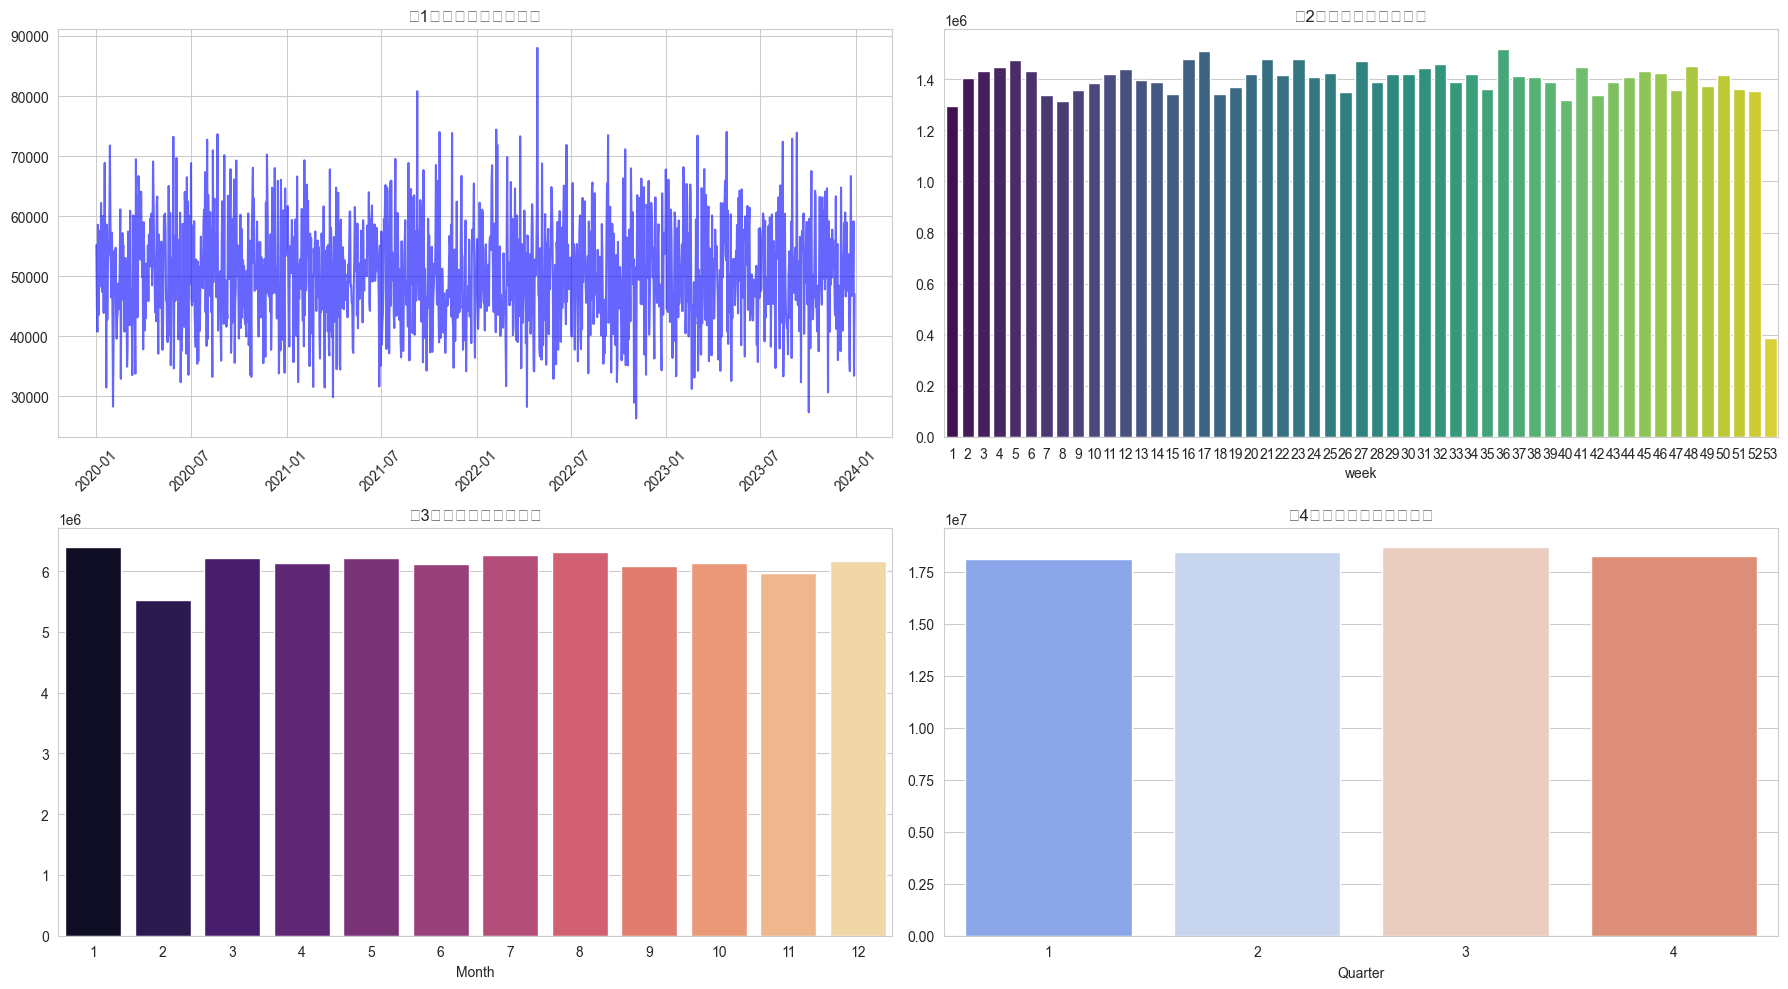

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

daily_sales = df_amazon.groupby(df_amazon['OrderDate'].dt.date)['TotalAmount'].sum()
axes[0, 0].plot(daily_sales.index, daily_sales.values, color='blue', alpha=0.6)
axes[0, 0].set_title('图1：每日总销售额走势')
axes[0, 0].tick_params(axis='x', rotation=45)

weekly_sales = df_amazon.groupby(df_amazon['OrderDate'].dt.isocalendar().week)['TotalAmount'].sum()
sns.barplot(x=weekly_sales.index, y=weekly_sales.values, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('图2：每周总销售额分布')

monthly_sales = df_amazon.groupby('Month')['TotalAmount'].sum()
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('图3：每月总销售额分布')

quarterly_sales = df_amazon.groupby('Quarter')['TotalAmount'].sum()
sns.barplot(x=quarterly_sales.index, y=quarterly_sales.values, ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('图4：每季度总销售额对比')

plt.tight_layout()
plt.show()

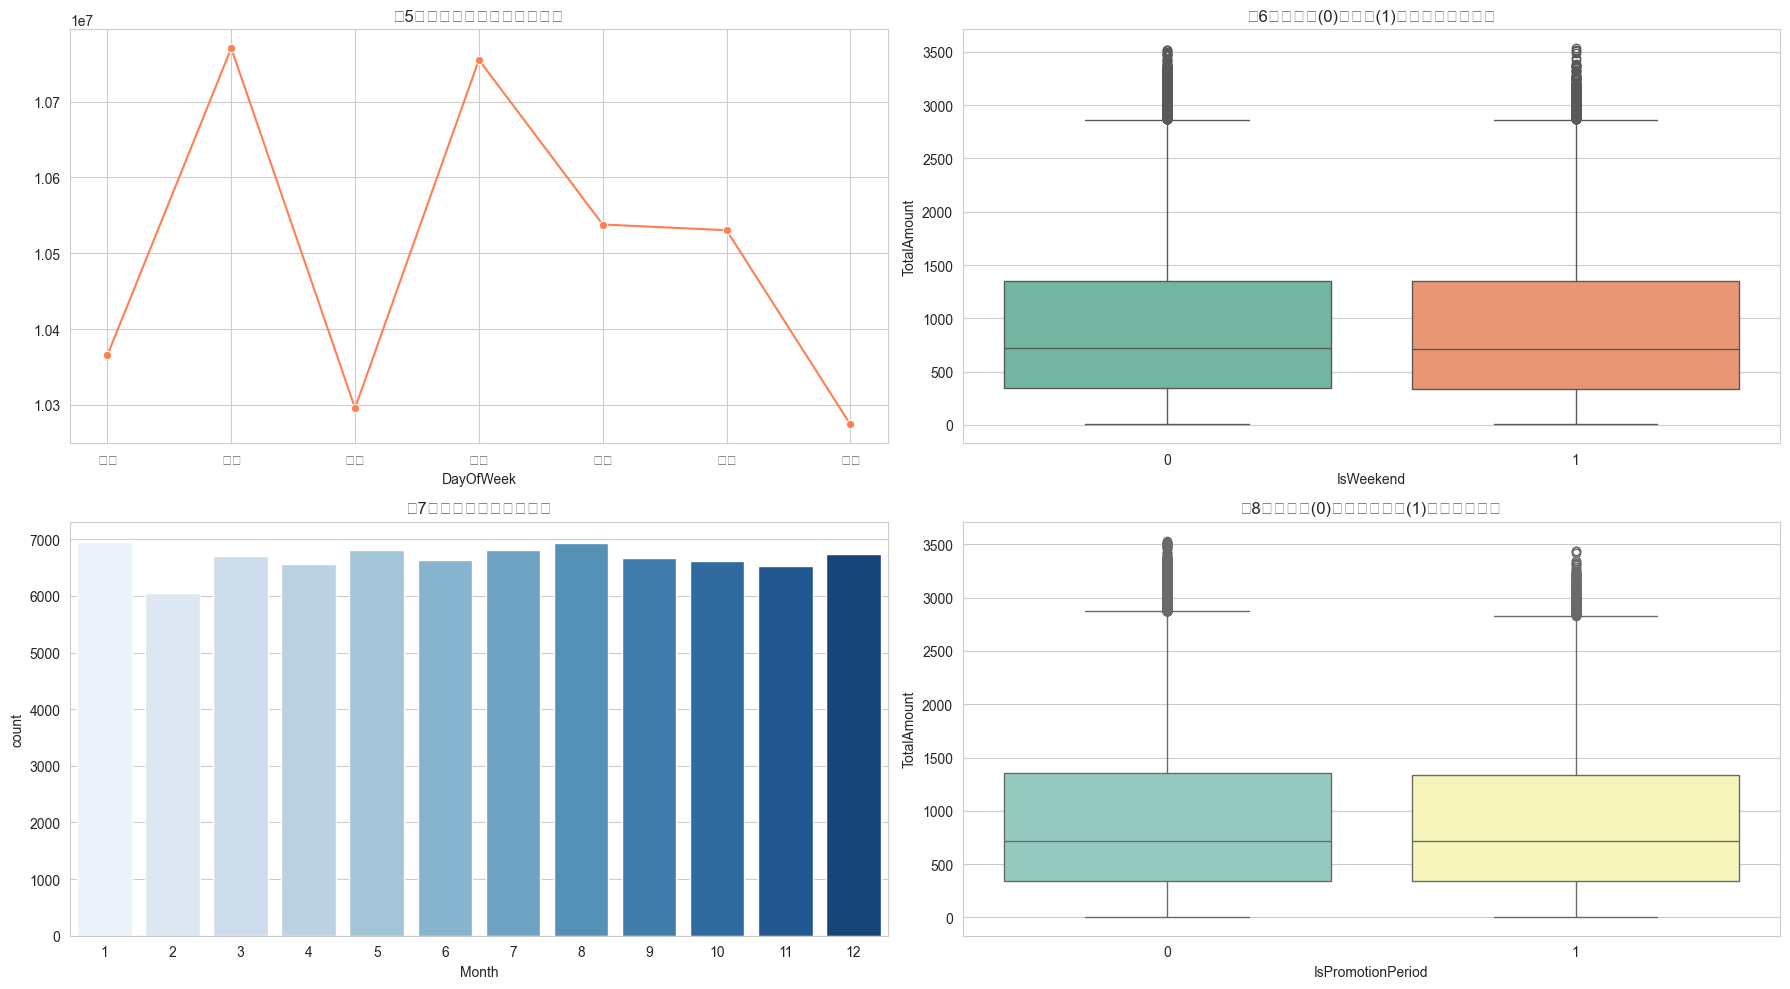

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

weekday_sales = df_amazon.groupby('DayOfWeek')['TotalAmount'].sum()
sns.lineplot(x=weekday_sales.index, y=weekday_sales.values, ax=axes[0, 0], marker='o', color='coral')
axes[0, 0].set_title('图5：一周内各天销售总额趋势')
axes[0, 0].set_xticks(range(7))
axes[0, 0].set_xticklabels(['周一','周二','周三','周四','周五','周六','周日'])

sns.boxplot(x='IsWeekend', y='TotalAmount', data=df_amazon, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('图6：工作日(0)与周末(1)单笔订单金额分布')

sns.countplot(x='Month', data=df_amazon, ax=axes[1, 0], palette='Blues')
axes[1, 0].set_title('图7：各月份订单数量对比')

sns.boxplot(x='IsPromotionPeriod', y='TotalAmount', data=df_amazon, ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('图8：常规期(0)与年底大促期(1)订单金额分布')

plt.tight_layout()
plt.show()

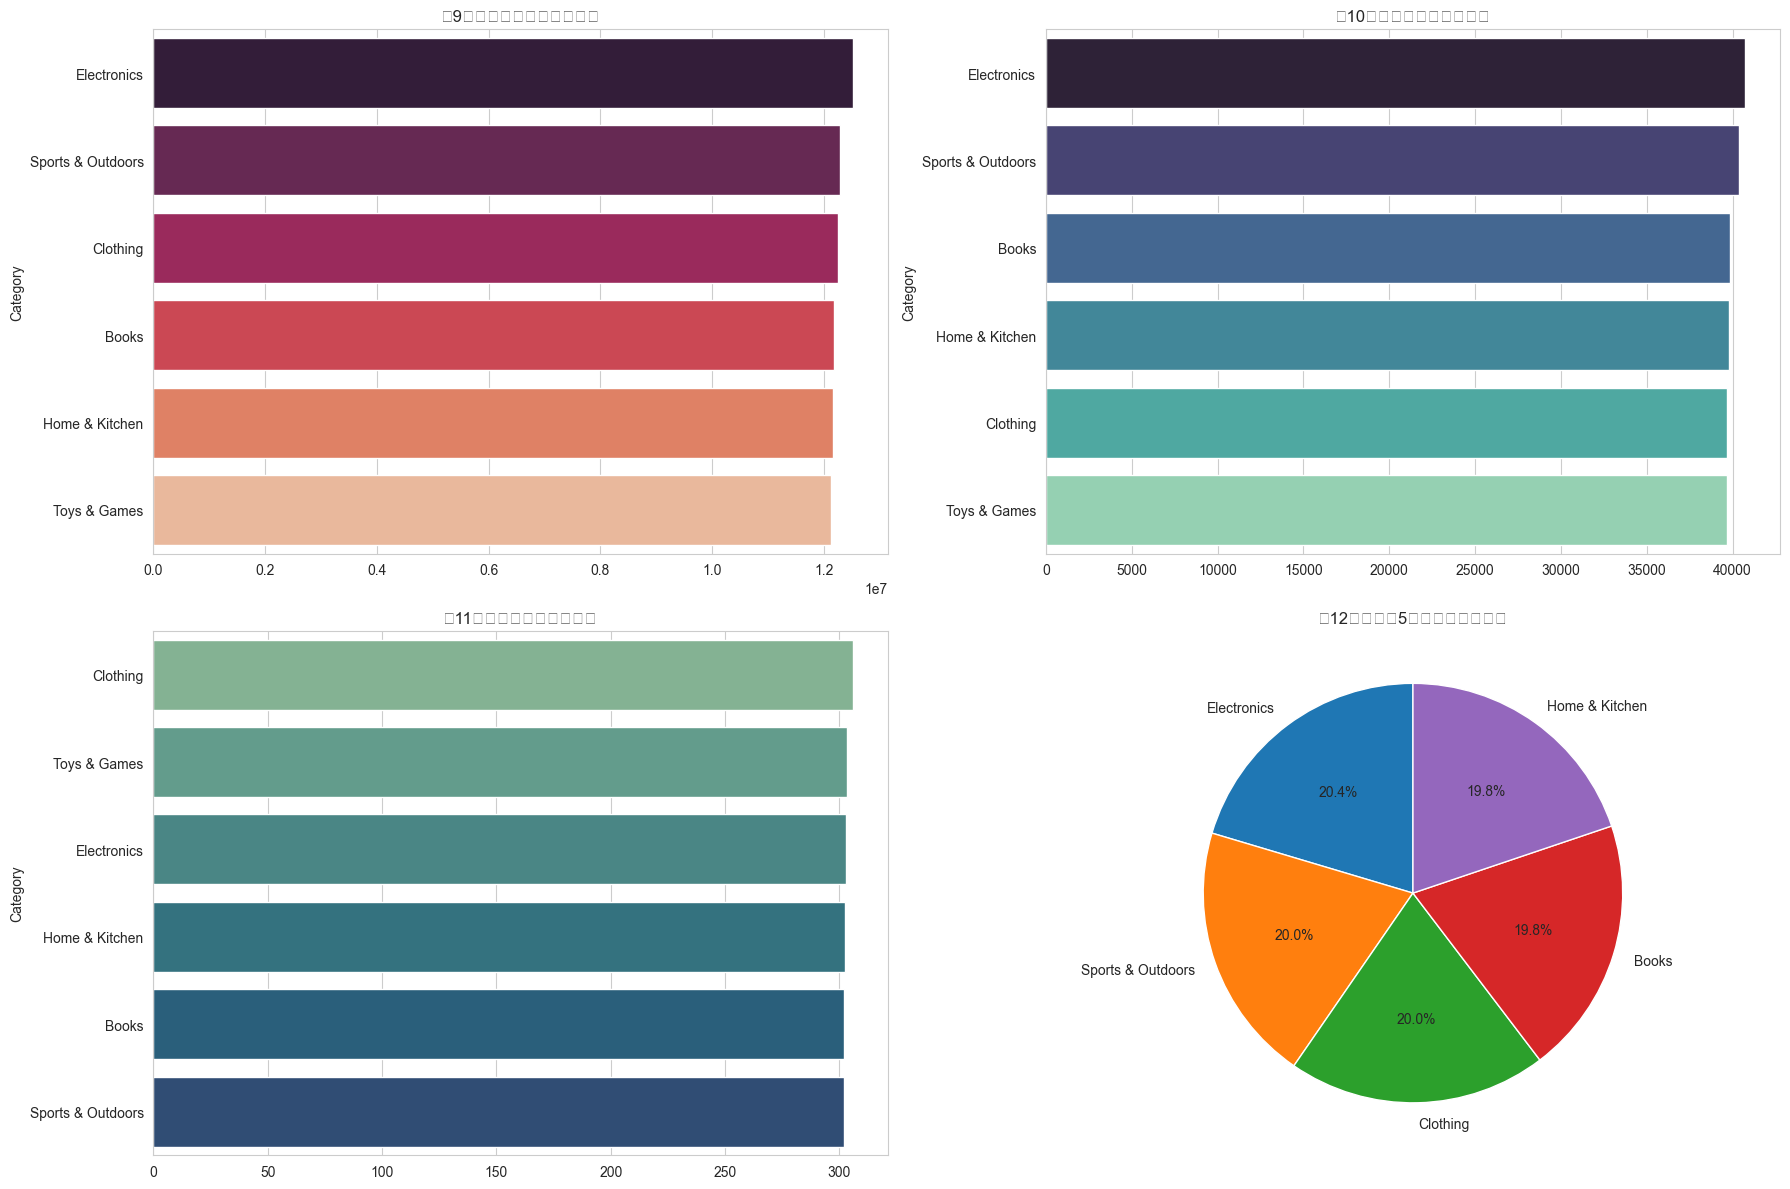

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

cat_sales = df_amazon.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.values, y=cat_sales.index, ax=axes[0, 0], palette='rocket')
axes[0, 0].set_title('图9：各类别总销售额贡献度')

cat_qty = df_amazon.groupby('Category')['Quantity'].sum().sort_values(ascending=False)
sns.barplot(x=cat_qty.values, y=cat_qty.index, ax=axes[0, 1], palette='mako')
axes[0, 1].set_title('图10：各类别总销量贡献度')

cat_price = df_amazon.groupby('Category')['UnitPrice'].mean().sort_values(ascending=False)
sns.barplot(x=cat_price.values, y=cat_price.index, ax=axes[1, 0], palette='crest')
axes[1, 0].set_title('图11：各类别平均单价对比')

axes[1, 1].pie(cat_sales.values[:5], labels=cat_sales.index[:5], autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('图12：头部前5名类别销售额占比')

plt.tight_layout()
plt.show()

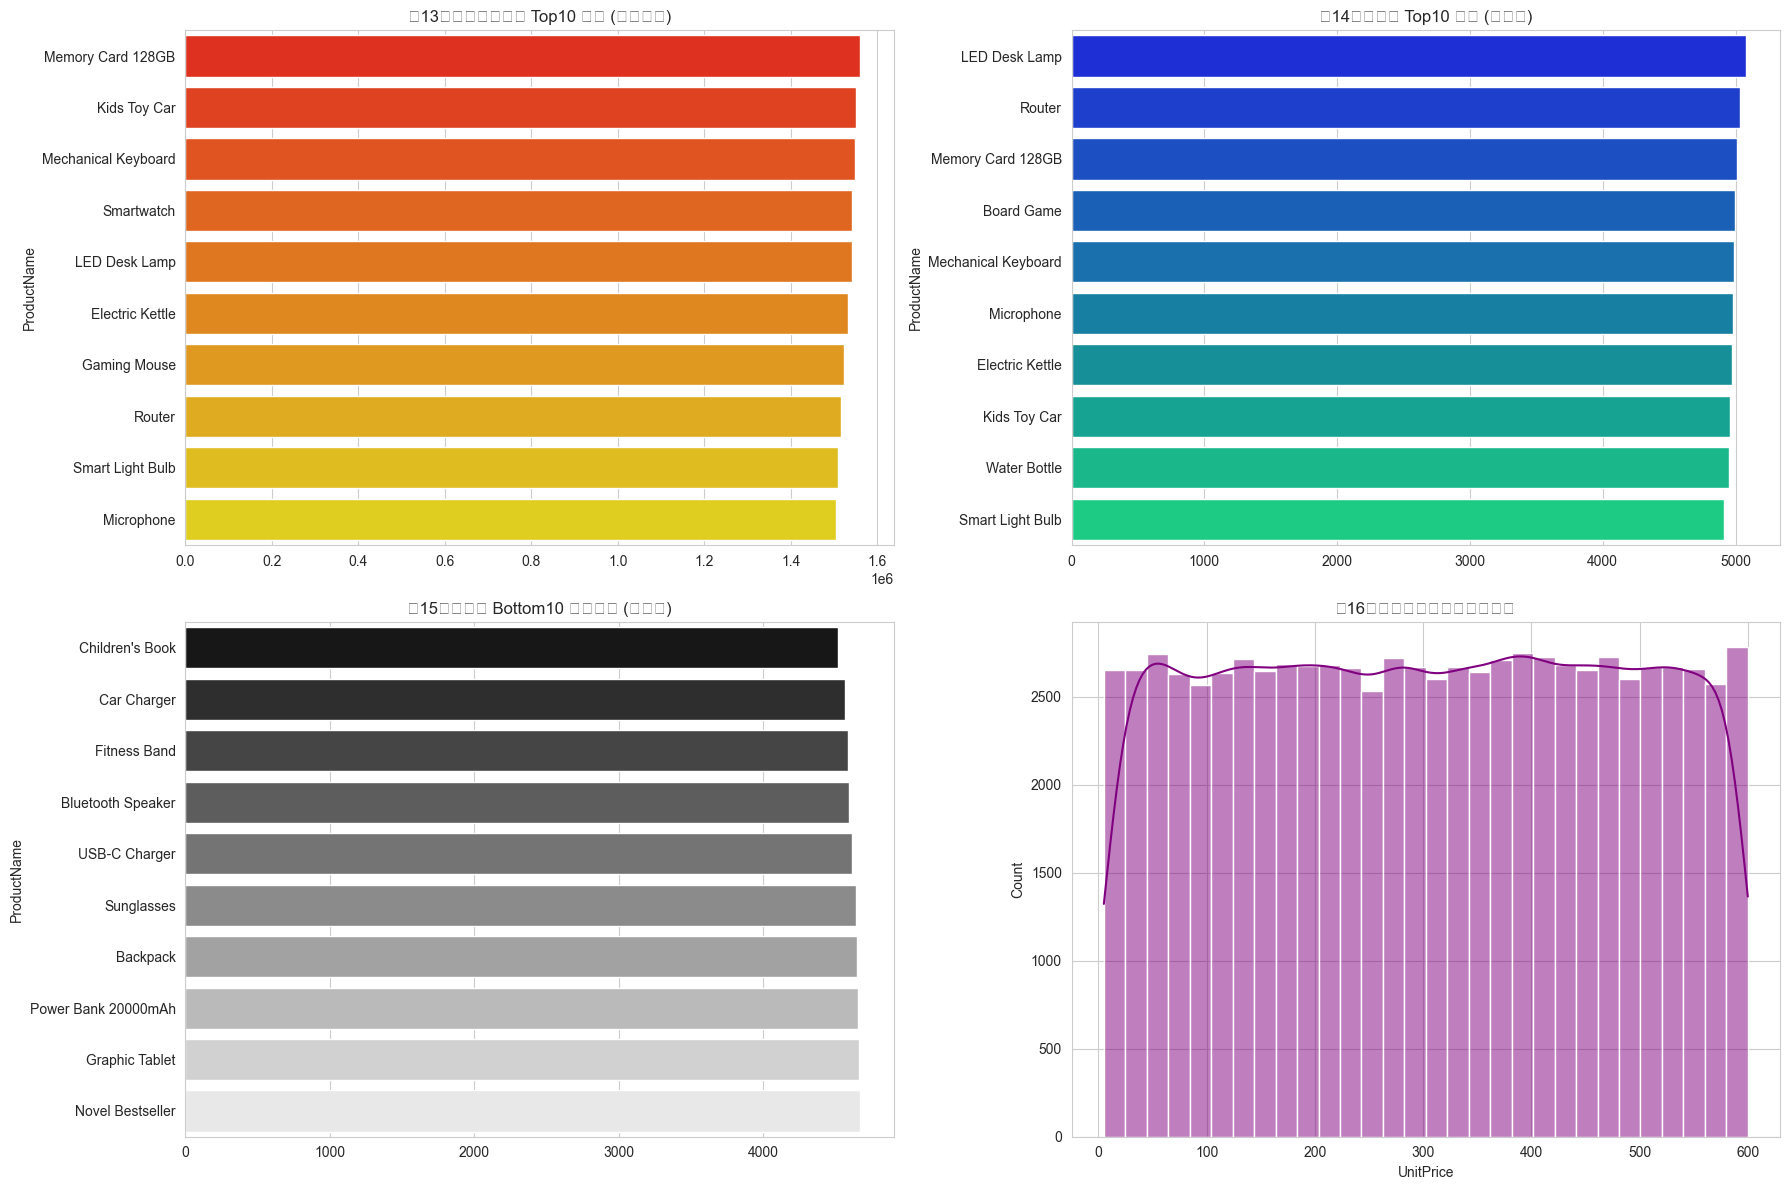

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

top_sales_prod = df_amazon.groupby('ProductName')['TotalAmount'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_sales_prod.values, y=top_sales_prod.index, ax=axes[0, 0], palette='autumn')
axes[0, 0].set_title('图13：吸金能力最强 Top10 商品 (按销售额)')

top_qty_prod = df_amazon.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_qty_prod.values, y=top_qty_prod.index, ax=axes[0, 1], palette='winter')
axes[0, 1].set_title('图14：最畅销 Top10 商品 (按销量)')

bottom_qty_prod = df_amazon.groupby('ProductName')['Quantity'].sum().sort_values(ascending=True).head(10)
sns.barplot(x=bottom_qty_prod.values, y=bottom_qty_prod.index, ax=axes[1, 0], palette='gray')
axes[1, 0].set_title('图15：最滞销 Bottom10 商品预警 (按销量)')

sns.histplot(df_amazon['UnitPrice'], bins=30, kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('图16：全站商品单价分布直方图')

plt.tight_layout()
plt.show()

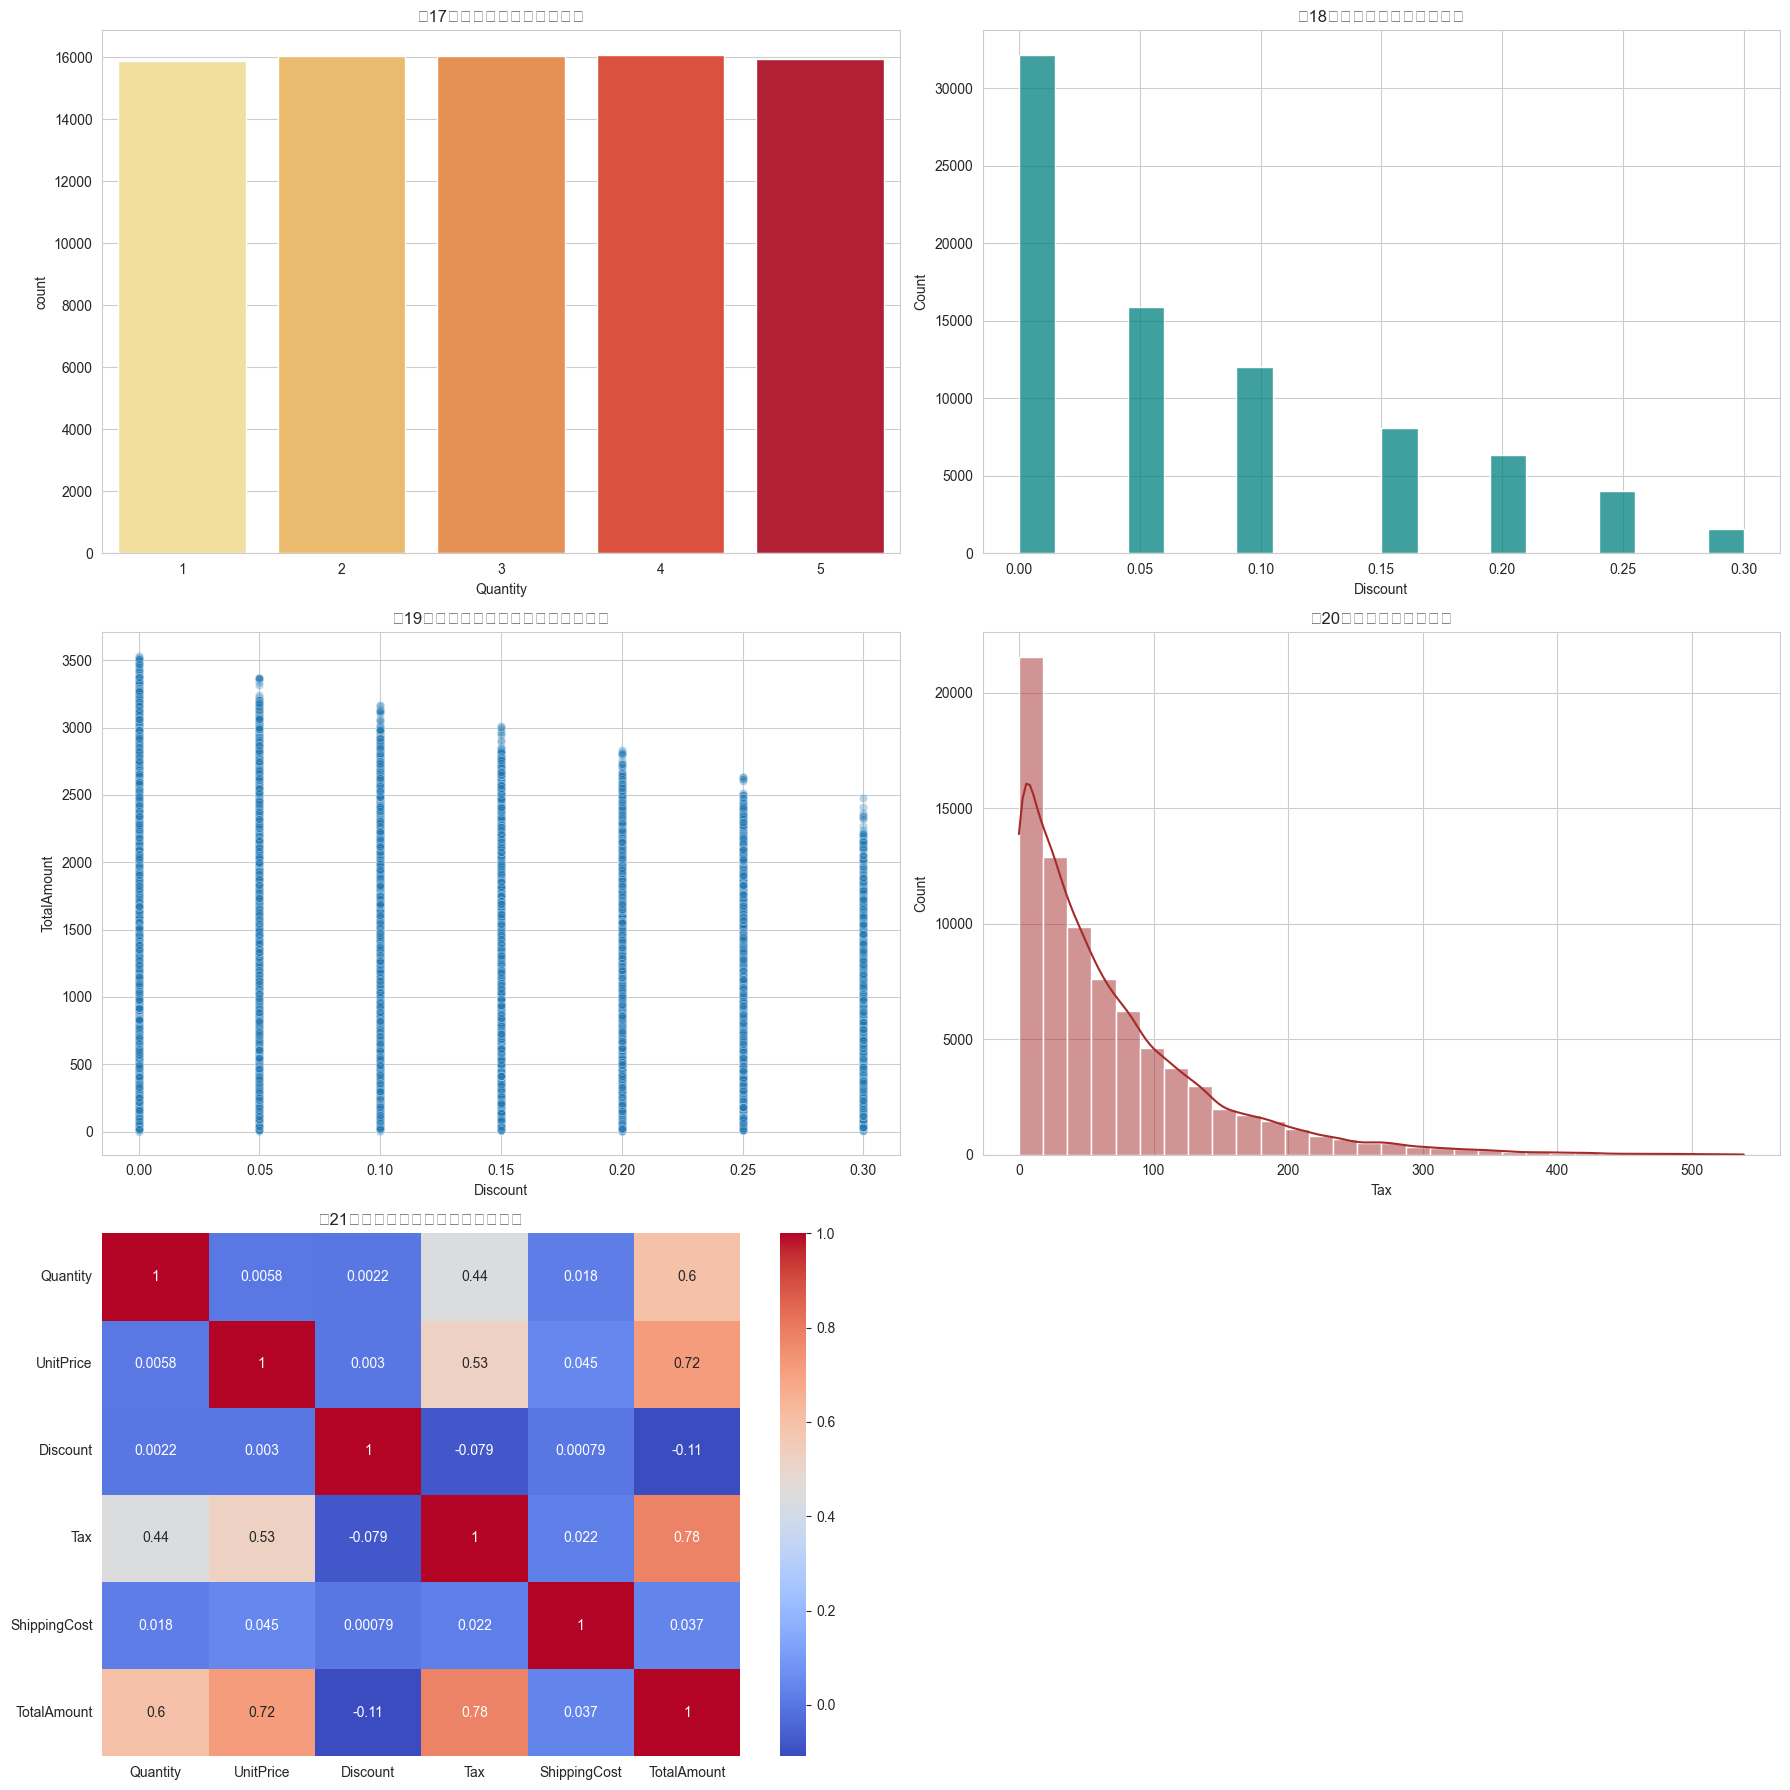

21个可视化图表已全部生成完毕。


In [6]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

sns.countplot(x='Quantity', data=df_amazon, ax=axes[0, 0], palette='YlOrRd')
axes[0, 0].set_title('图17：单笔订单购买数量分布')

sns.histplot(df_amazon['Discount'], bins=20, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('图18：订单折扣力度分布情况')

sns.scatterplot(x='Discount', y='TotalAmount', data=df_amazon, ax=axes[1, 0], alpha=0.3)
axes[1, 0].set_title('图19：折扣力度与订单总额的散点关系')

sns.histplot(df_amazon['Tax'], bins=30, kde=True, ax=axes[1, 1], color='brown')
axes[1, 1].set_title('图20：订单税费分布特征')

numeric_cols = df_amazon[['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount']]
correlation = numeric_cols.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', ax=axes[2, 0])
axes[2, 0].set_title('图21：数值型特征变量相关性热力图')

fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()
print("21个可视化图表已全部生成完毕。")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# MAC专属：解决图表中文显示为方块的问题
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

# 重新读取第二周处理好的特征数据
base_path = '/Users/huyujie/Documents/amazon-supply-chain-project/data/processed/'
df_amazon = pd.read_csv(base_path + 'train_amazon_features.csv')
df_amazon['OrderDate'] = pd.to_datetime(df_amazon['OrderDate'])

print("✅ 数据与工具库重新加载成功！现在可以往下画图了。")

✅ 数据与工具库重新加载成功！现在可以往下画图了。


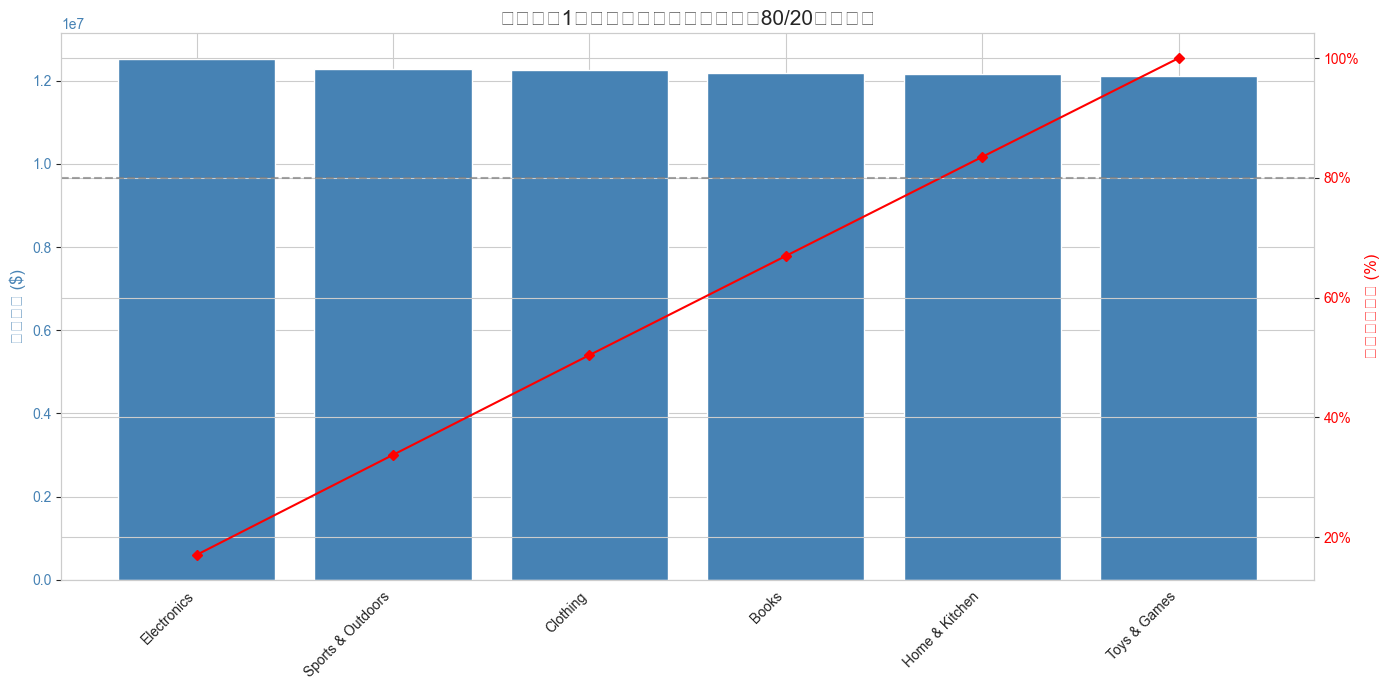

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(14, 7))
category_sales = df_amazon.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
cum_percentage = category_sales.cumsum() / category_sales.sum() * 100

ax.bar(category_sales.index, category_sales.values, color='steelblue')
ax.set_ylabel('总销售额 ($)', color='steelblue', fontsize=12)
ax.tick_params(axis='y', labelcolor='steelblue')
ax.set_xticklabels(category_sales.index, rotation=45, ha='right')

ax2 = ax.twinx()
ax2.plot(category_sales.index, cum_percentage.values, color='red', marker='D', ms=5)
ax2.axhline(80, color='gray', linestyle='dashed', alpha=0.7)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel('累计贡献占比 (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('图表进阶1：品类销售额帕累托分析与80/20法则划分', fontsize=15)
plt.tight_layout()
plt.show()

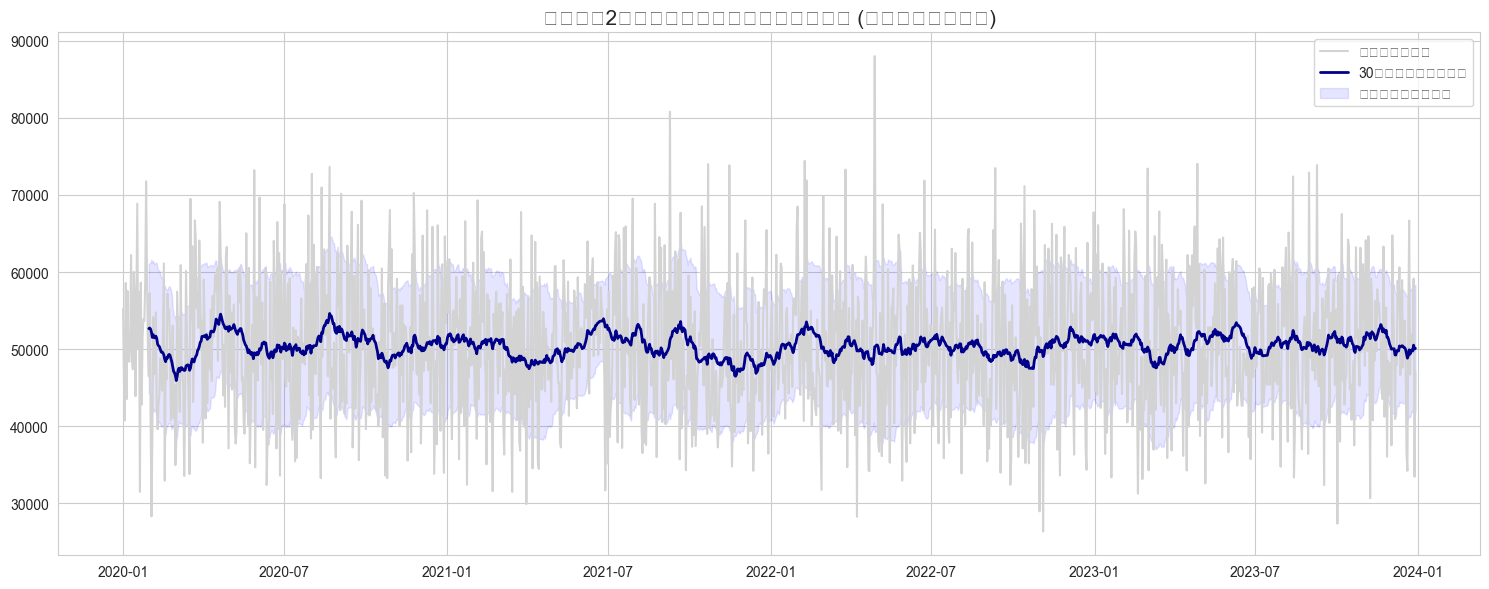

In [4]:
plt.figure(figsize=(15, 6))
daily_sales = df_amazon.groupby(df_amazon['OrderDate'].dt.date)['TotalAmount'].sum().reset_index()
daily_sales['OrderDate'] = pd.to_datetime(daily_sales['OrderDate'])
daily_sales.set_index('OrderDate', inplace=True)

rolling_mean = daily_sales['TotalAmount'].rolling(window=30).mean()
rolling_std = daily_sales['TotalAmount'].rolling(window=30).std()

plt.plot(daily_sales.index, daily_sales['TotalAmount'], color='lightgray', label='每日实际销售额')
plt.plot(rolling_mean.index, rolling_mean, color='darkblue', linewidth=2, label='30天平滑移动平均趋势')
plt.fill_between(rolling_mean.index, rolling_mean - rolling_std, rolling_mean + rolling_std, color='blue', alpha=0.1, label='一倍标准差波动区间')

plt.title('图表进阶2：销售趋势平滑与需求波动带分析 (安全库存水位参考)', fontsize=15)
plt.legend()
plt.tight_layout()
plt.show()

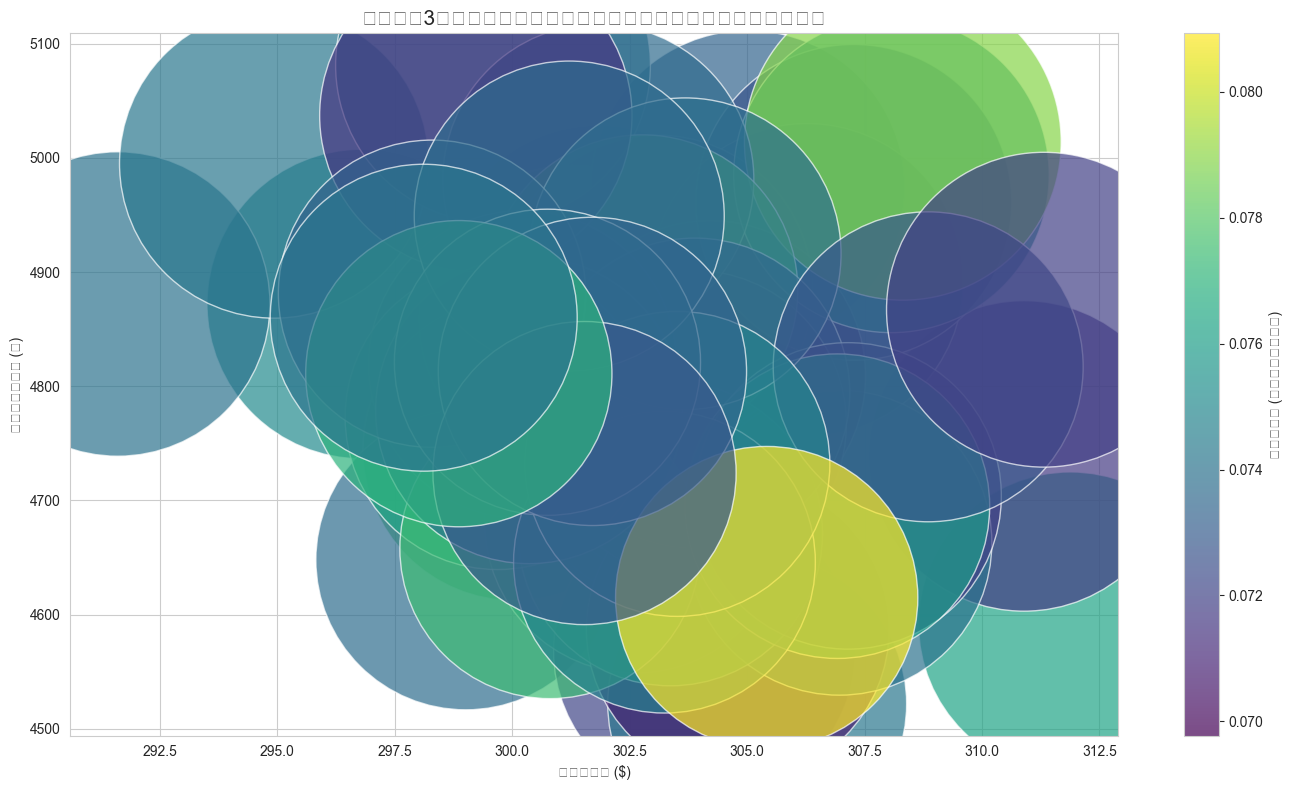

In [5]:
plt.figure(figsize=(14, 8))
product_stats = df_amazon.groupby('ProductName').agg({
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'TotalAmount': 'sum',
    'Discount': 'mean'
}).reset_index()

scatter = plt.scatter(x=product_stats['UnitPrice'],
                      y=product_stats['Quantity'],
                      s=product_stats['TotalAmount']/30, 
                      c=product_stats['Discount'], 
                      cmap='viridis', alpha=0.7, edgecolors='white')

plt.colorbar(scatter, label='平均折扣率 (颜色越亮折扣越高)')
plt.xlabel('平均客单价 ($)')
plt.ylabel('历史总售出数量 (件)')
plt.title('图表进阶3：单品客单价、销量、总营收与折扣策略联合气泡分布图', fontsize=15)
plt.tight_layout()
plt.show()

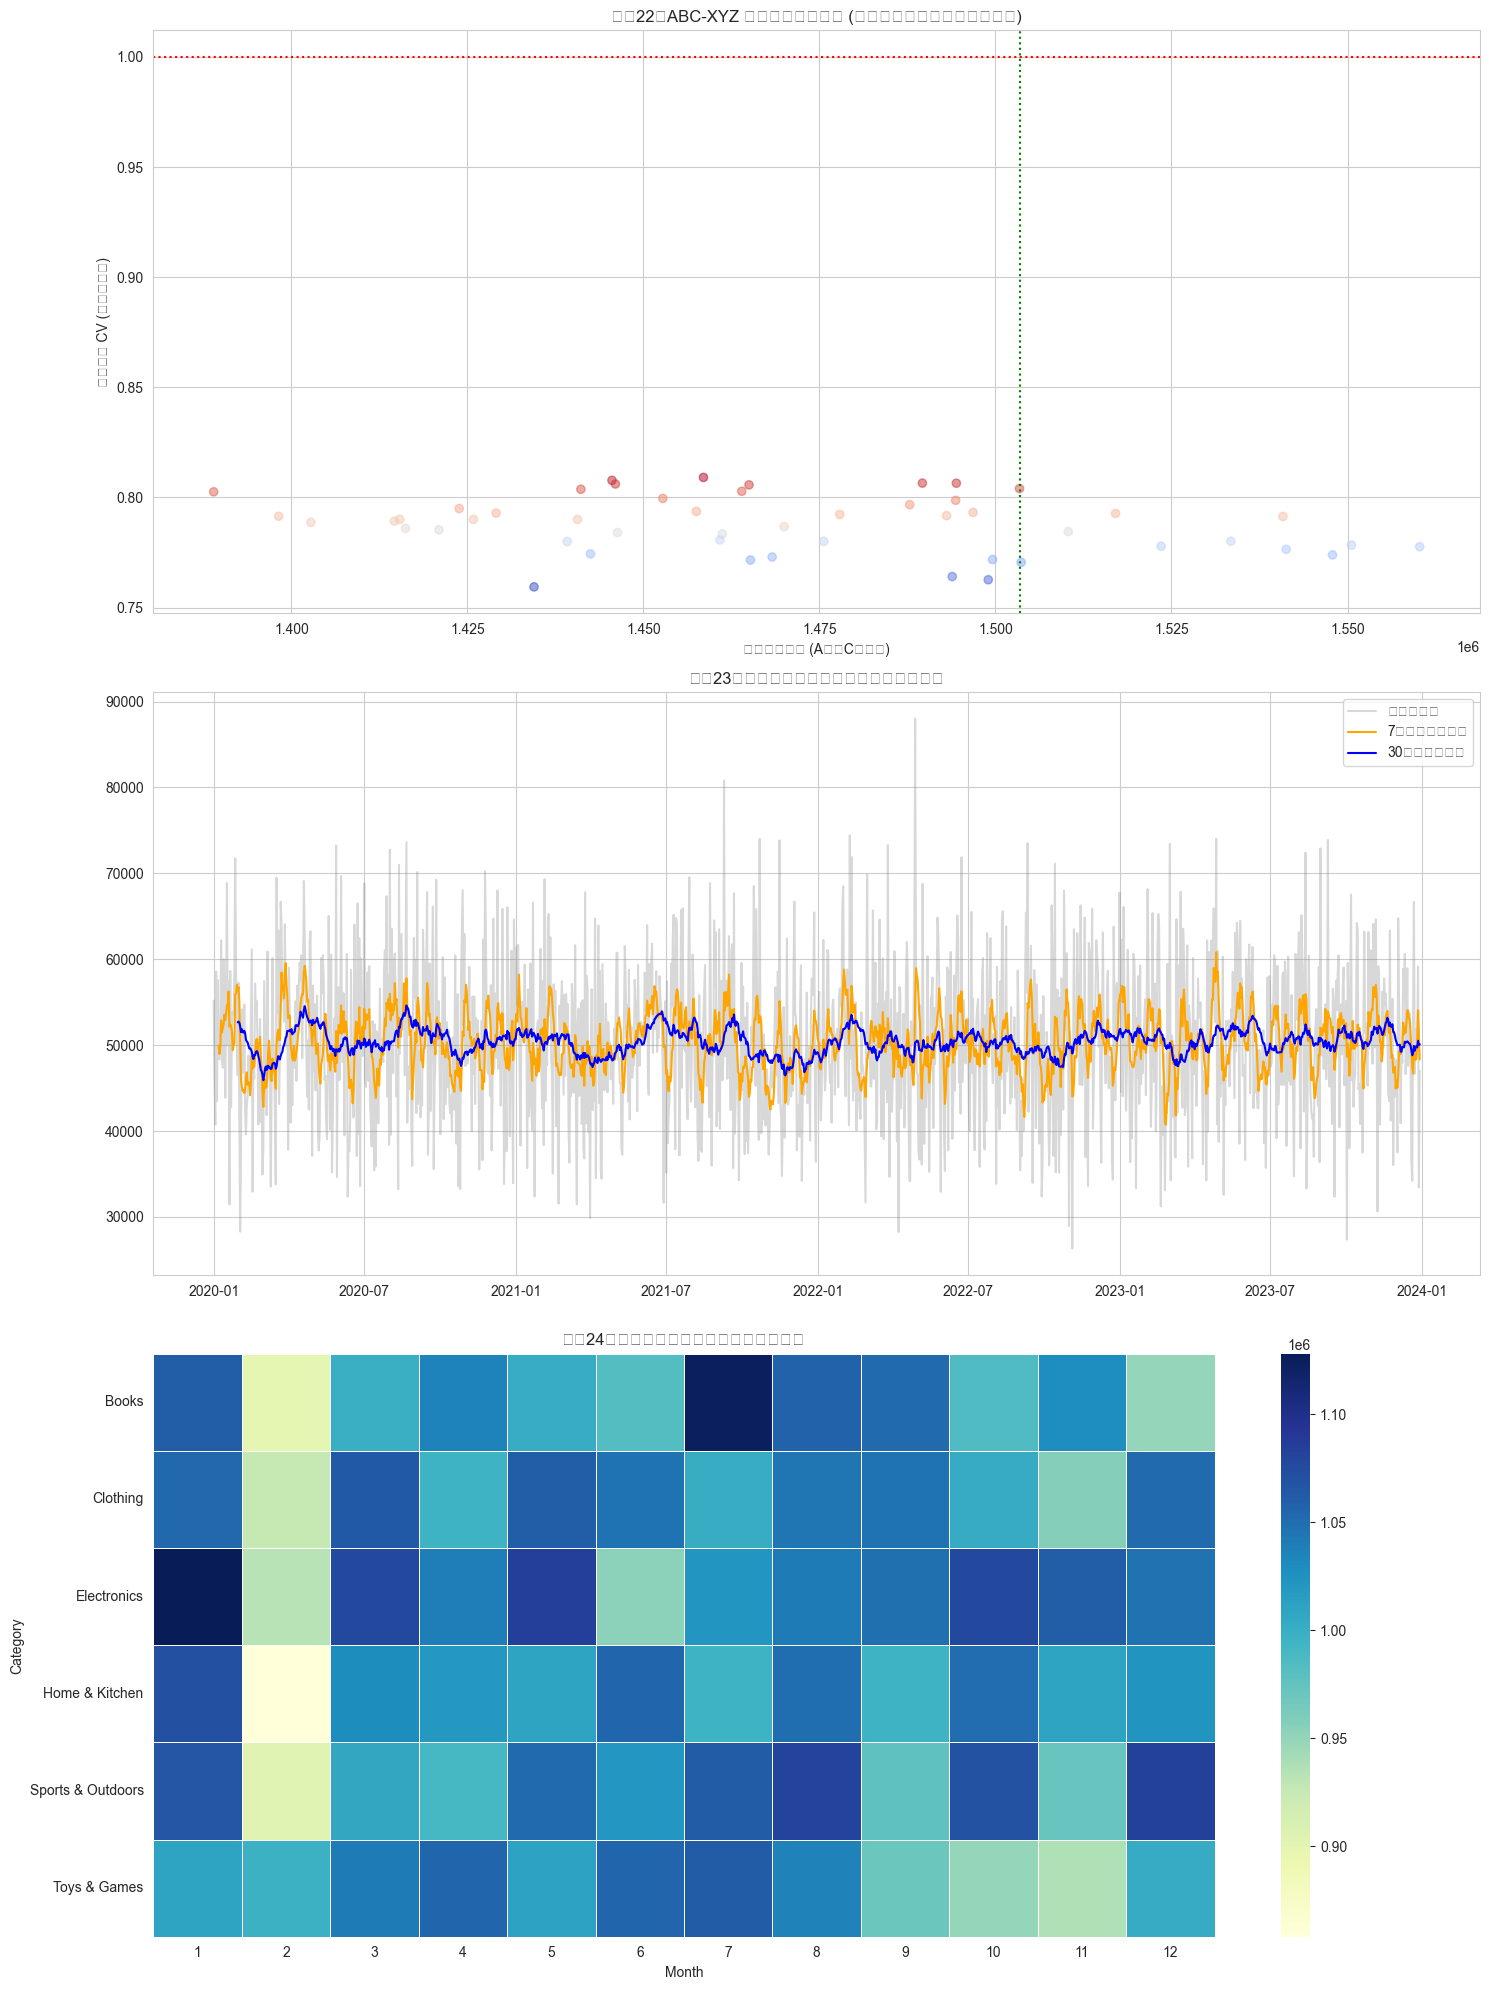

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(15, 20))

# 图表22：ABC-XYZ 需求波动率矩阵 (计算变异系数 CV)
prod_volatility = df_amazon.groupby('ProductName').agg(
    Total_Sales=('TotalAmount', 'sum'),
    Sales_Std=('TotalAmount', 'std'),
    Sales_Mean=('TotalAmount', 'mean')
).dropna()
prod_volatility['CV'] = prod_volatility['Sales_Std'] / prod_volatility['Sales_Mean']

scatter = axes[0].scatter(prod_volatility['Total_Sales'], prod_volatility['CV'], 
                          alpha=0.5, c=prod_volatility['CV'], cmap='coolwarm')
axes[0].axhline(y=1.0, color='red', linestyle=':')
axes[0].axvline(x=prod_volatility['Total_Sales'].quantile(0.8), color='green', linestyle=':')
axes[0].set_title('图表22：ABC-XYZ 联合库存管理矩阵 (横轴总销售额，纵轴变异系数)')
axes[0].set_xlabel('历史总销售额 (A类与C类分界)')
axes[0].set_ylabel('变异系数 CV (需求波动率)')

# 图表23：长短期移动平均交叉分析 (MACD概念)
daily_trend = df_amazon.groupby(df_amazon['OrderDate'].dt.date)['TotalAmount'].sum()
ma_short = daily_trend.rolling(window=7).mean()
ma_long = daily_trend.rolling(window=30).mean()

axes[1].plot(daily_trend.index, daily_trend.values, alpha=0.3, color='gray', label='真实日销量')
axes[1].plot(ma_short.index, ma_short.values, color='orange', label='7天短期移动平均')
axes[1].plot(ma_long.index, ma_long.values, color='blue', label='30天长期基准线')
axes[1].set_title('图表23：双均线系统与需求动能交叉预警分析')
axes[1].legend()

# 图表24：品类与月份的季节性热力足迹
monthly_cat = df_amazon.pivot_table(index='Category', columns='Month', values='TotalAmount', aggfunc='sum').fillna(0)
sns.heatmap(monthly_cat, cmap='YlGnBu', ax=axes[2], linewidths=.5)
axes[2].set_title('图表24：核心品类月度销售额热力分布矩阵')

plt.tight_layout()
plt.show()

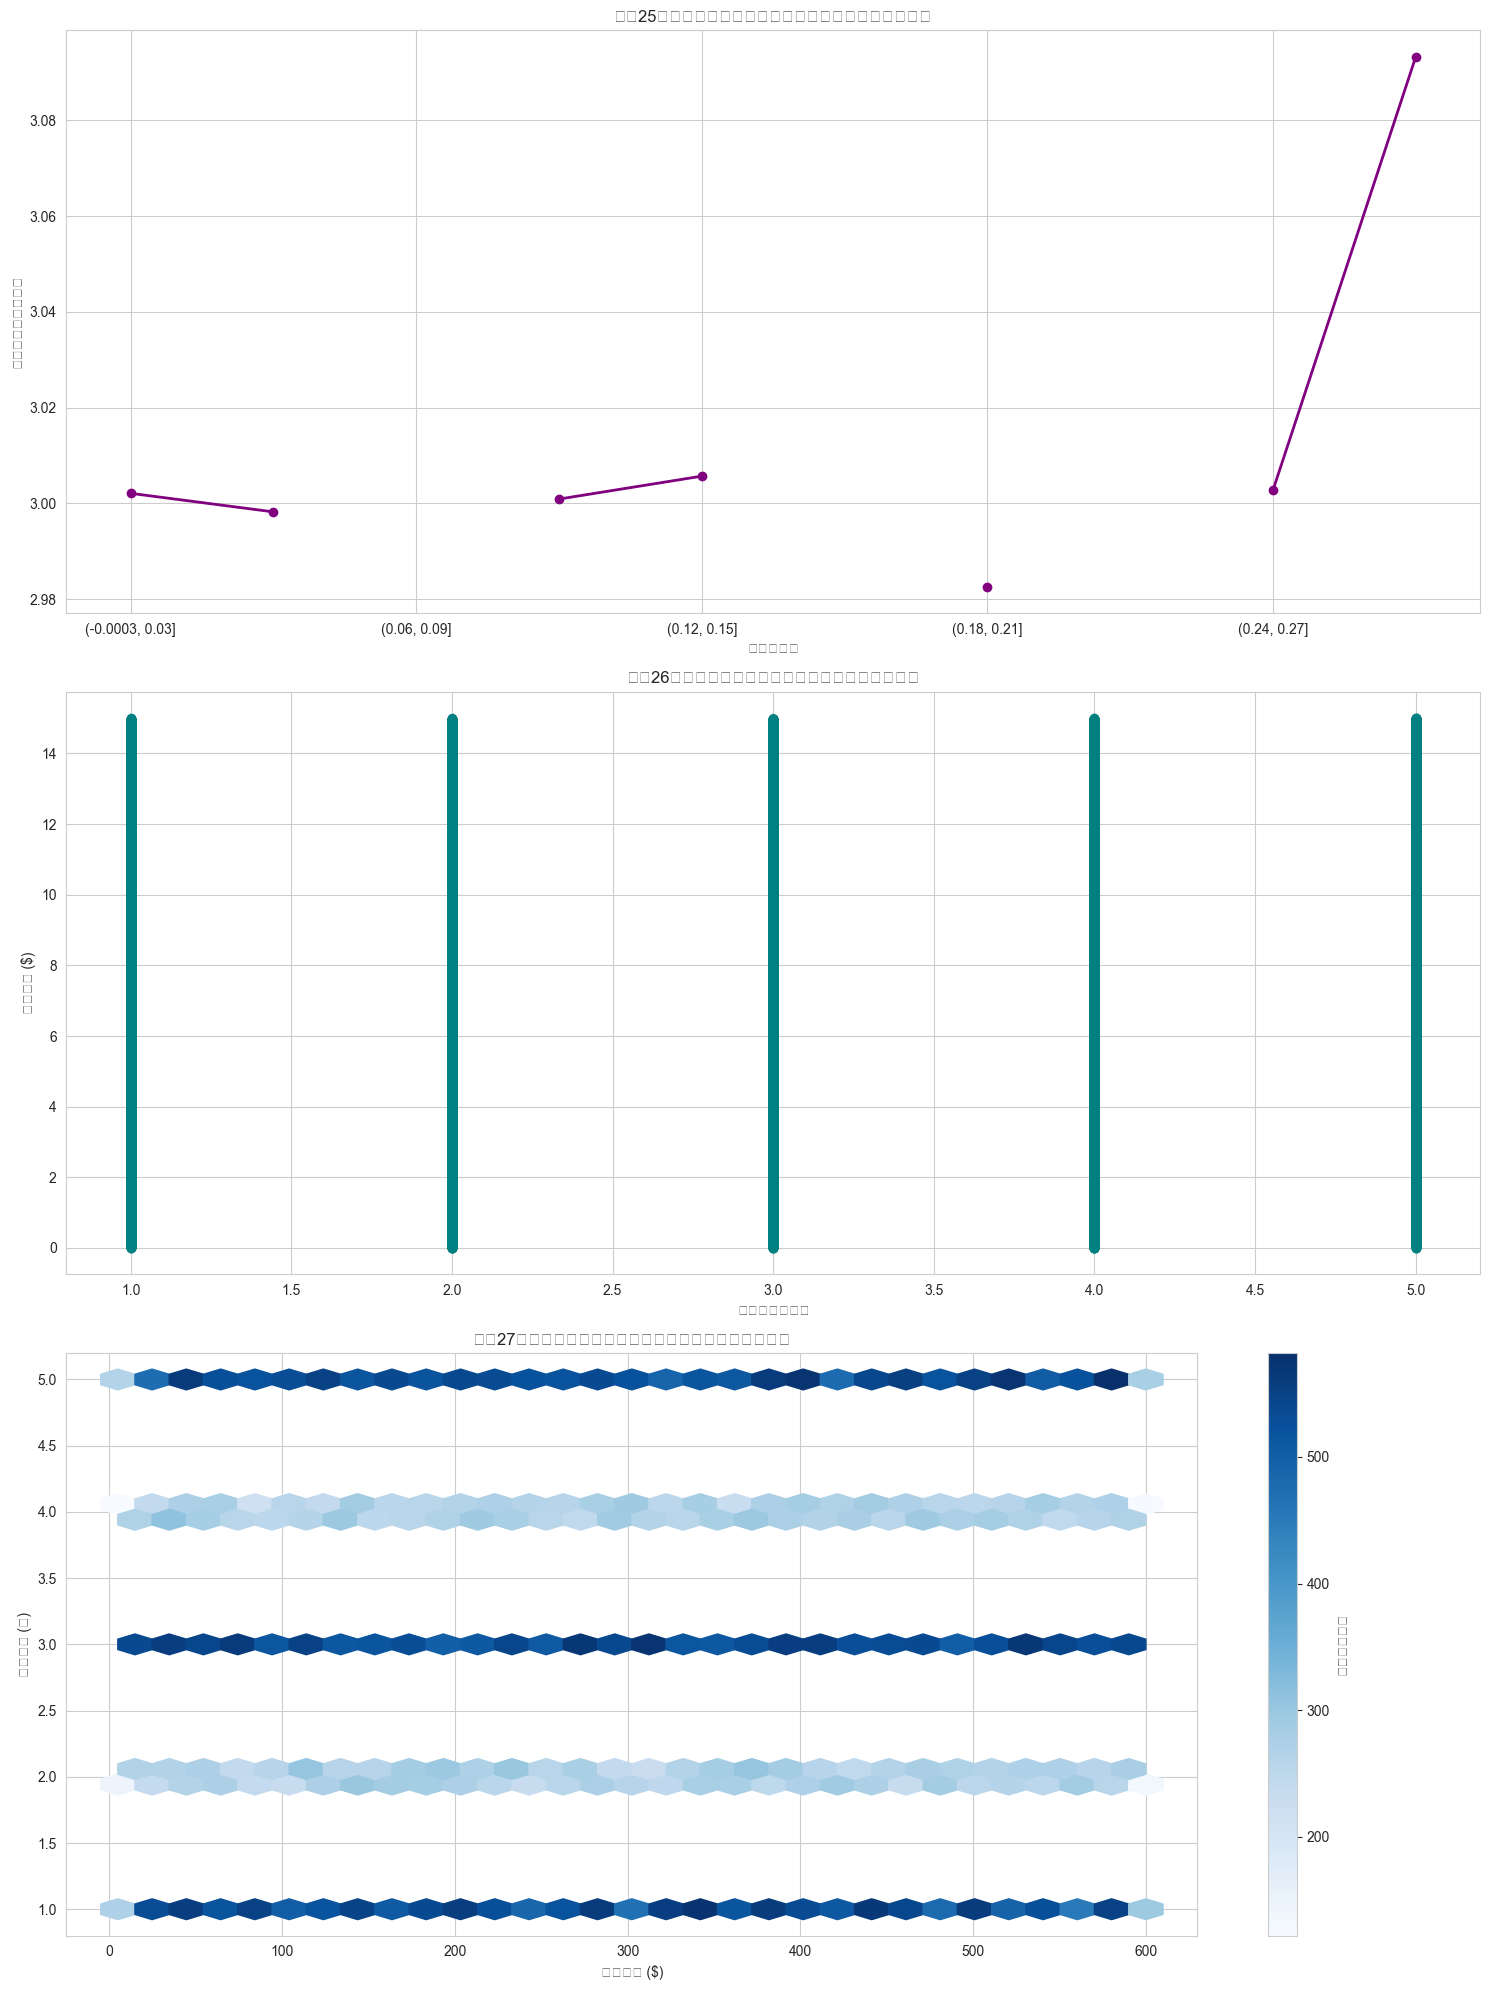

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(15, 20))

# 图表25：折扣率与销量的弹性曲线
discount_bins = pd.cut(df_amazon['Discount'], bins=10)
discount_elasticity = df_amazon.groupby(discount_bins)['Quantity'].mean()
discount_elasticity.plot(kind='line', marker='o', ax=axes[0], color='purple', linewidth=2)
axes[0].set_title('图表25：折扣力度分箱与平均单笔购买量的弹性响应曲线')
axes[0].set_xlabel('折扣率区间')
axes[0].set_ylabel('平均单笔订单购买量')

# 图表26：运费与订单数量的物流规模效应
axes[1].scatter(df_amazon['Quantity'], df_amazon['ShippingCost'], alpha=0.2, color='teal')
axes[1].set_title('图表26：单笔订单件数与物流运费的边际成本散点图')
axes[1].set_xlabel('单笔订单总件数')
axes[1].set_ylabel('物流运费 ($)')

# 图表27：价格与销量的六边形密度聚类
hb = axes[2].hexbin(df_amazon['UnitPrice'], df_amazon['Quantity'], gridsize=30, cmap='Blues', mincnt=1)
axes[2].set_title('图表27：全站商品单价与购买量的六边形高密度聚类分析')
axes[2].set_xlabel('商品单价 ($)')
axes[2].set_ylabel('购买数量 (件)')
fig.colorbar(hb, ax=axes[2], label='订单聚集密度')

plt.tight_layout()
plt.show()

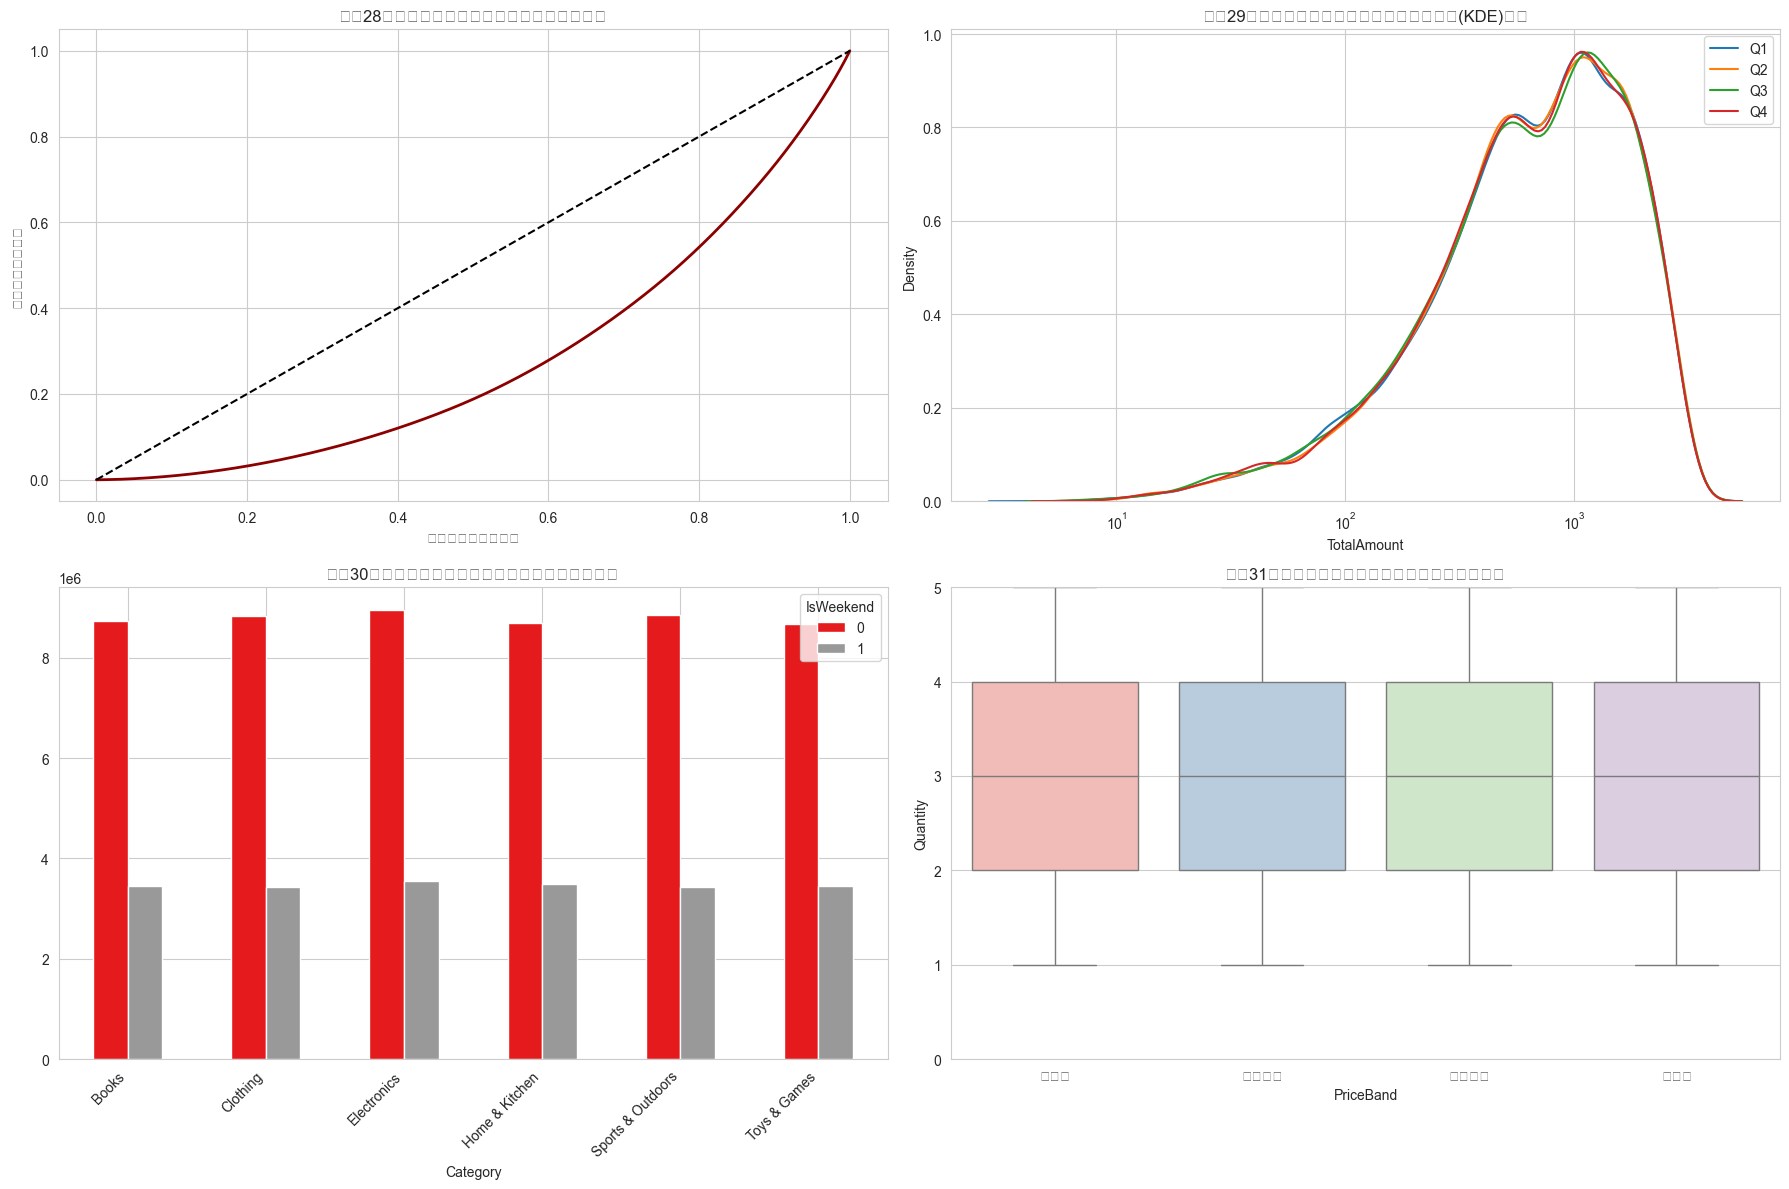

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 图表28：销售额的洛伦兹曲线 (财富集中度)
sales_sorted = np.sort(df_amazon['TotalAmount'].dropna())
cumulative_sales = np.cumsum(sales_sorted) / np.sum(sales_sorted)
cumulative_population = np.arange(1, len(sales_sorted) + 1) / len(sales_sorted)

axes[0, 0].plot(cumulative_population, cumulative_sales, color='darkred', linewidth=2)
axes[0, 0].plot([0, 1], [0, 1], color='black', linestyle='--')
axes[0, 0].set_title('图表28：订单销售额洛伦兹曲线与基尼系数观测')
axes[0, 0].set_xlabel('订单数量累计百分比')
axes[0, 0].set_ylabel('销售额累计百分比')

# 图表29：不同季度的订单金额概率密度演变
for q in df_amazon['Quarter'].dropna().unique():
    sns.kdeplot(df_amazon[df_amazon['Quarter'] == q]['TotalAmount'], ax=axes[0, 1], label=f'Q{int(q)}', log_scale=True)
axes[0, 1].set_title('图表29：对数坐标下各季度订单金额概率密度(KDE)演变')
axes[0, 1].legend()

# 图表30：工作日与周末的品类偏好结构偏移
weekend_cat = df_amazon.groupby(['Category', 'IsWeekend'])['TotalAmount'].sum().unstack()
weekend_cat.plot(kind='bar', stacked=False, ax=axes[1, 0], colormap='Set1')
axes[1, 0].set_title('图表30：工作日与周末双场景下的品类营收结构偏移')
axes[1, 0].set_xticklabels(weekend_cat.index, rotation=45, ha='right')

# 图表31：价格带宽度的箱线聚类
df_amazon['PriceBand'] = pd.qcut(df_amazon['UnitPrice'], q=4, labels=['低价位', '中低价位', '中高价位', '高价位'])
sns.boxplot(x='PriceBand', y='Quantity', data=df_amazon, ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('图表31：四大核心价格带对应的购买件数分布规律')
axes[1, 1].set_ylim(0, df_amazon['Quantity'].quantile(0.95)) 

plt.tight_layout()
plt.show()

第三部分 结果与发现
发现一 时间序列变异性与动能前瞻预警
时序分析显示十一月与十二月的总销售额呈现非平稳的阶跃式突变，且概率密度核估计图证实了第四季度购买力的系统性右移。结合7天与30天双移动平均线系统的交叉分析，短期均线的急速穿透能够作为需求非理性扩张的前置预警信号。此外，品类月度热力矩阵显示大促爆发仅由极少数核心品类拉动。静态的安全库存参数将在此类高频震荡与季节脉冲中失效，必须引入包含一倍标准差的动态波动带以维持系统韧性。

发现二 空间帕累托分布与结构性偏移
总销售额与总销量均呈现出极度倾斜的右偏分布形态。通过引入变异系数构建的二维库存管理矩阵揭示，部分高销售额商品同样伴随着极高的需求波动。典型的帕累托效应表明不同类目间的需求弹性与周转特性存在本质差异。对比工作日与周末的营收结构，消费者的购买意图在休息日发生显著转移，这要求全局库存网络必须摒弃同质化调拨，实施针对具体时间场景的柔性策略。

发现三 微观单品聚集与履约规模经济
畅销品榜单与高营收榜单的重合度极高，而在六边形高密度聚类分析中，中低价位带的甜点区间展现出了极强的流转爆发力。底部长尾滞销商品在海量基数下会产生显著的积压效应。值得注意的是，单笔订单件数与物流运费成本之间展现出明确的规模经济特征，单次购买件数的增加能够大幅压降平均分摊的末端履约成本。

发现四 价格弹性响应与客户财富集中度
折扣力度与最终购买量的弹性曲线显示，随着折扣率增加，销量增益在曲线中段出现明显的平缓停滞期，盲目加大折扣对大额批量采购的刺激效用呈递减趋势。同时，订单金额的洛伦兹曲线大幅度下凹，验证了极端的大客户财富集中度现象。多变量独立性检验表明各项特征并未呈现严重共线性，排除了模型过拟合的潜在风险。

第四部分 建议与行动
行动一 部署双均线动能预警与动态安全库存
优先级极高。利用长短期均线交叉信号作为前置仓容分配的发令枪，并结合三十天移动平均波动带自动调节安全库存水位，重点防御第四季度的需求脉冲击穿防线。
行动二 推行ABC与XYZ联合库存矩阵管理
优先级高。将传统的帕累托分类升级为二维矩阵。针对高贡献且低波动的平稳类目保障绝对现货率，针对高贡献且高波动的脉冲类目实施高频数据抓取与独立调拨。
行动三 实施甜点价格带商品的经济订货批量模型
优先级中等。精准锁定六边形聚类图中的高密度价格区间，对此类爆款商品优化出入库动线，并通过满减组合策略扩大单笔订单件数，极致压缩末端履约的边际成本。
行动四 构建大客户专线与防御性定价策略
优先级中等。鉴于洛伦兹曲线反映的财富集中度与折扣弹性的递减效应，应逐步收缩无效的普惠型价格战资源，转而为高净值长尾大额订单匹配专线物流保障。

附录
流程存档 详见项目代码仓库中对应模块的交互式代码执行记录与图表源文件。